In [ ]:
#  2 RGB to grayscale conversion.

In [1]:
!pip install numba tensorflow matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from numba import cuda

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Image Shape: (32, 32, 3)


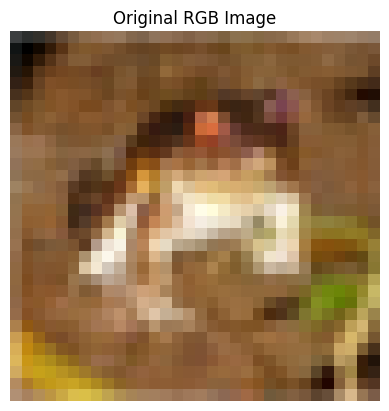

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

img = x_train[0]
img = np.ascontiguousarray(img)
print("Image Shape:", img.shape)

plt.imshow(img)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

In [4]:
@cuda.jit
def rgb_to_gray(rgb, gray):

    x, y = cuda.grid(2)

    if x < rgb.shape[0] and y < rgb.shape[1]:

        r = rgb[x, y, 0]
        g = rgb[x, y, 1]
        b = rgb[x, y, 2]

        gray[x, y] = (
            0.299 * r +
            0.587 * g +
            0.114 * b
        )

In [5]:
gray = np.zeros(
    (img.shape[0], img.shape[1]),
    dtype=np.uint8
)

d_rgb = cuda.to_device(img)
d_gray = cuda.to_device(gray)

threads_per_block = (16, 16)

blocks_x = (
    img.shape[0] +
    threads_per_block[0] - 1
) // threads_per_block[0]

blocks_y = (
    img.shape[1] +
    threads_per_block[1] - 1
) // threads_per_block[1]

rgb_to_gray[
    (blocks_x, blocks_y),
    threads_per_block
](d_rgb, d_gray)

cuda.synchronize()

gray_result = d_gray.copy_to_host()

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


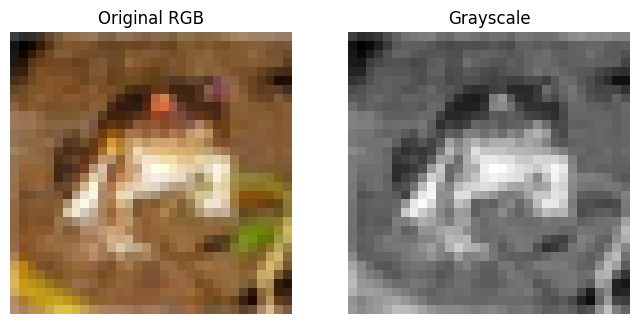

In [6]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_result, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.show()